In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")

DATA_DIR = "../data"

train = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=["date"])
test = pd.read_csv(f"{DATA_DIR}/test.csv", parse_dates=["date"])
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")
oil = pd.read_csv(f"{DATA_DIR}/oil.csv", parse_dates=["date"])
holidays = pd.read_csv(f"{DATA_DIR}/holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv(f"{DATA_DIR}/transactions.csv", parse_dates=["date"])

print("train:", train.shape)
print("test:", test.shape)
print("stores:", stores.shape)
print("oil:", oil.shape)
print("holidays:", holidays.shape)
print("transactions:", transactions.shape)

train: (3000888, 6)
test: (28512, 5)
stores: (54, 5)
oil: (1218, 2)
holidays: (350, 6)
transactions: (83488, 3)


In [3]:
print("=== TRAIN ===")
display(train.head())
print(train.dtypes)
print()

print("=== TEST ===")
display(test.head())
print()

print("=== STORES ===")
display(stores.head())
print()

print("=== OIL ===")
display(oil.head())
print()

print("=== HOLIDAYS ===")
display(holidays.head())
print()

print("=== TRANSACTIONS ===")
display(transactions.head())

=== TRAIN ===


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object

=== TEST ===


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0



=== STORES ===


...

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20



=== HOLIDAYS ===


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False



=== TRANSACTIONS ===


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [5]:
n_stores = train["store_nbr"].nunique()
n_families = train["family"].nunique()
n_dates = train["date"].nunique()

print("Number of stores:", n_stores)
print("Number of product families:", n_families)
print("Number of unique dates:", n_dates)
print("Product (stores × families × dates):", n_stores * n_families * n_dates)
print("Actual number of rows in train:", len(train))

Number of stores: 54
Number of product families: 33
Number of unique dates: 1684
Product (stores × families × dates): 3000888
Actual number of rows in train: 3000888


In [6]:
print("Train date range:", train["date"].min(), "-", train["date"].max())
print("Test date range:", test["date"].min(), "-", test["date"].max())
print()
print("Product families:")
print(train["family"].unique())
print()
print("Sales distribution:")
print(train["sales"].describe())

Train date range: 2013-01-01 00:00:00 - 2017-08-15 00:00:00
Test date range: 2017-08-16 00:00:00 - 2017-08-31 00:00:00

Product families:
<ArrowStringArray>
[                'AUTOMOTIVE',                  'BABY CARE',
                     'BEAUTY',                  'BEVERAGES',
                      'BOOKS',               'BREAD/BAKERY',
                'CELEBRATION',                   'CLEANING',
                      'DAIRY',                       'DELI',
                       'EGGS',               'FROZEN FOODS',
                  'GROCERY I',                 'GROCERY II',
                   'HARDWARE',         'HOME AND KITCHEN I',
        'HOME AND KITCHEN II',            'HOME APPLIANCES',
                  'HOME CARE',                 'LADIESWEAR',
            'LAWN AND GARDEN',                   'LINGERIE',
           'LIQUOR,WINE,BEER',                  'MAGAZINES',
                      'MEATS',              'PERSONAL CARE',
               'PET SUPPLIES',    'PLAYERS AND ELE

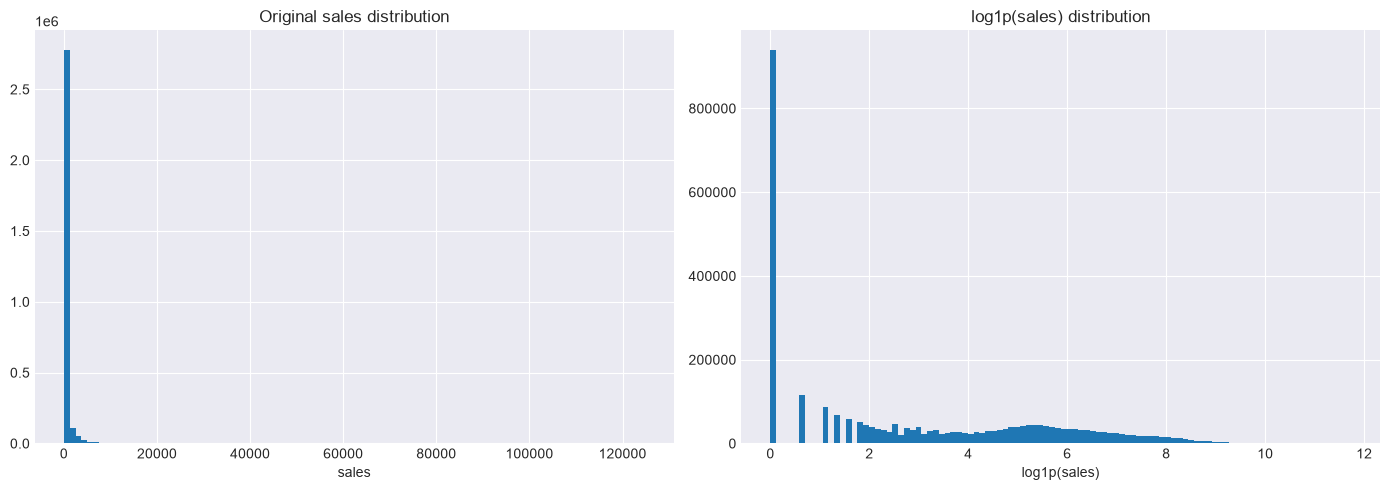

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train["sales"], bins=100)
axes[0].set_title("Original sales distribution")
axes[0].set_xlabel("sales")

axes[1].hist(np.log1p(train["sales"]), bins=100)
axes[1].set_title("log1p(sales) distribution")
axes[1].set_xlabel("log1p(sales)")

plt.tight_layout()
plt.show()

In [8]:
zero_pct = (train["sales"] == 0).mean() * 100
print(f"Percentage of rows with zero sales: {zero_pct:.2f}%")

zero_by_family = train.groupby("family")["sales"].apply(lambda x: (x == 0).mean() * 100).sort_values(ascending=False)
print("\nZero-sales percentage by family (top 10):")
print(zero_by_family.head(10))

Percentage of rows with zero sales: 31.30%

Zero-sales percentage by family (top 10):
family
BOOKS                         96.955001
BABY CARE                     94.131037
SCHOOL AND OFFICE SUPPLIES    74.082871
HOME APPLIANCES               73.517639
LADIESWEAR                    59.846485
MAGAZINES                     56.538665
PET SUPPLIES                  54.615334
HARDWARE                      47.862233
LAWN AND GARDEN               46.784552
PLAYERS AND ELECTRONICS       44.886514
Name: sales, dtype: float64


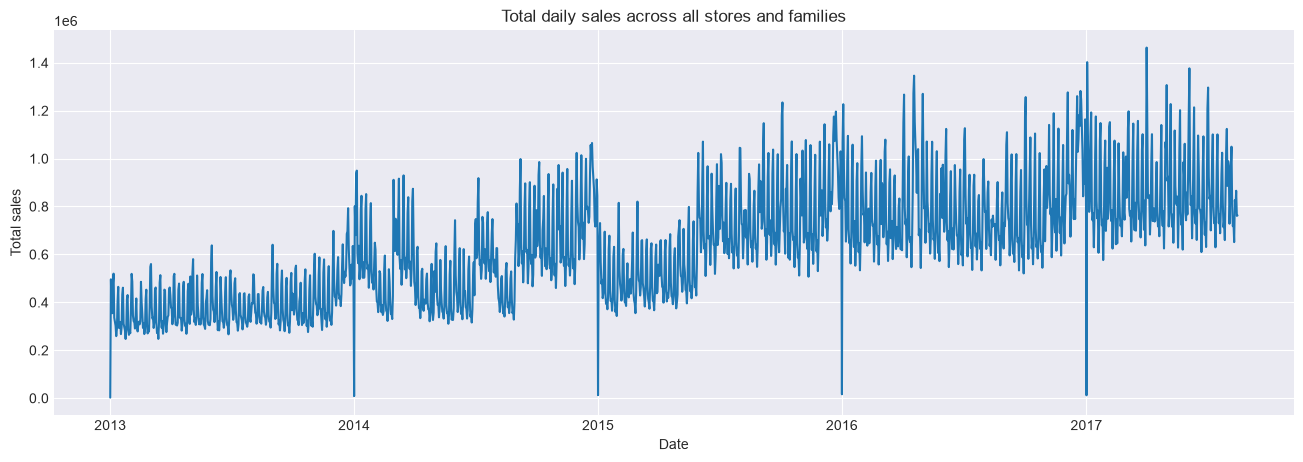

In [9]:
daily_sales = train.groupby("date")["sales"].sum()

plt.figure(figsize=(16, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Total daily sales across all stores and families")
plt.xlabel("Date")
plt.ylabel("Total sales")
plt.show()

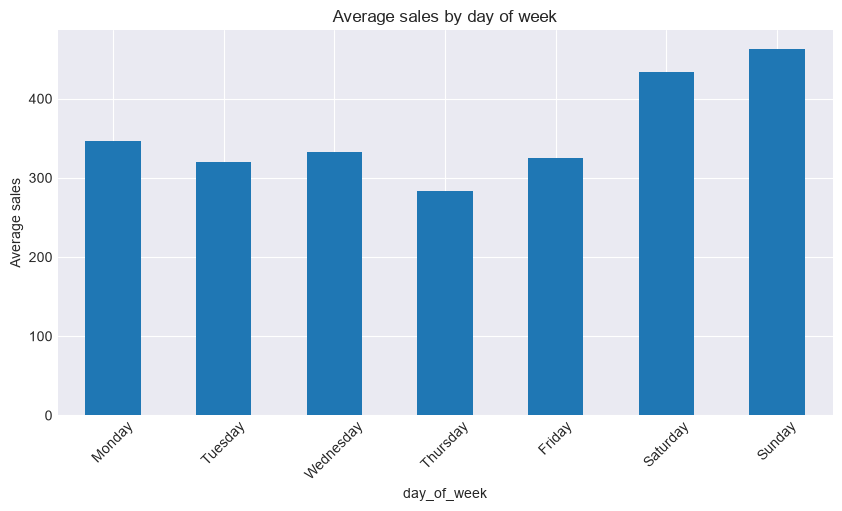

In [10]:
train["day_of_week"] = train["date"].dt.day_name()

weekday_avg = train.groupby("day_of_week")["sales"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.figure(figsize=(10, 5))
weekday_avg.plot(kind="bar")
plt.title("Average sales by day of week")
plt.ylabel("Average sales")
plt.xticks(rotation=45)
plt.show()

In [11]:
print(holidays["type"].value_counts())
print()
print(holidays["locale"].value_counts())
print()
print(holidays["transferred"].value_counts())

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

transferred
False    338
True      12
Name: count, dtype: int64


In [12]:
transferred_holidays = holidays[holidays["transferred"] == True]
transfer_days = holidays[holidays["type"] == "Transfer"]

print("=== Holidays marked as transferred (should NOT count as day off) ===")
display(transferred_holidays[["date", "type", "locale", "description", "transferred"]])

print("\n=== Transfer days (these ARE the actual day off) ===")
display(transfer_days[["date", "type", "locale", "description", "transferred"]])

=== Holidays marked as transferred (should NOT count as day off) ===


,date,type,locale,description,transferred
19,2012-10-09,Holiday,National,Independencia de Guayaquil,True
72,2013-10-09,Holiday,National,Independencia de Guayaquil,True
135,2014-10-09,Holiday,National,Independencia de Guayaquil,True
255,2016-05-24,Holiday,National,Batalla de Pichincha,True
266,2016-07-25,Holiday,Local,Fundacion de Guayaquil,True
268,2016-08-10,Holiday,National,Primer Grito de Independencia,True
297,2017-01-01,Holiday,National,Primer dia del ano,True
303,2017-04-12,Holiday,Local,Fundacion de Cuenca,True
312,2017-05-24,Holiday,National,Batalla de Pichincha,True
324,2017-08-10,Holiday,National,Primer Grito de Independencia,True



=== Transfer days (these ARE the actual day off) ===


,date,type,locale,description,transferred
20,2012-10-12,Transfer,National,Traslado Independencia de Guayaquil,False
73,2013-10-11,Transfer,National,Traslado Independencia de Guayaquil,False
136,2014-10-10,Transfer,National,Traslado Independencia de Guayaquil,False
256,2016-05-27,Transfer,National,Traslado Batalla de Pichincha,False
265,2016-07-24,Transfer,Local,Traslado Fundacion de Guayaquil,False
269,2016-08-12,Transfer,National,Traslado Primer Grito de Independencia,False
298,2017-01-02,Transfer,National,Traslado Primer dia del ano,False
304,2017-04-13,Transfer,Local,Fundacion de Cuenca,False
313,2017-05-26,Transfer,National,Traslado Batalla de Pichincha,False
325,2017-08-11,Transfer,National,Traslado Primer Grito de Independencia,False


In [13]:
# Holiday NOT transferred = real day off
real_holidays = holidays[(holidays["type"] == "Holiday") & (holidays["transferred"] == False)]

# Transfer = the actual day off (where the holiday was moved to)
transfer_days = holidays[holidays["type"] == "Transfer"]

# Additional and Bridge = extra days off
additional_days = holidays[holidays["type"].isin(["Additional", "Bridge"])]

# Combine all actual non-working days
actual_holidays = pd.concat([real_holidays, transfer_days, additional_days])

print("Number of actual non-working holiday days:", len(actual_holidays))

Number of actual non-working holiday days: 277


In [14]:
print("Missing values in oil:", oil["dcoilwtico"].isna().sum())
print("Oil date range:", oil["date"].min(), "-", oil["date"].max())
print()

# merge oil prices with daily total sales
oil_sales = daily_sales.reset_index().merge(oil, on="date", how="left")
oil_sales.columns = ["date", "total_sales", "oil_price"]

print(oil_sales.head(10))

Missing values in oil: 43
Oil date range: 2013-01-01 00:00:00 - 2017-08-31 00:00:00

        date    total_sales  oil_price
0 2013-01-01    2511.618999        NaN
1 2013-01-02  496092.417944      93.14
2 2013-01-03  361461.231124      92.97
3 2013-01-04  354459.677093      93.12
4 2013-01-05  477350.121229        NaN
5 2013-01-06  519695.401088        NaN
6 2013-01-07  336122.801066      93.20
7 2013-01-08  318347.777981      93.21
8 2013-01-09  302530.809018      93.08
9 2013-01-10  258982.003049      93.81


In [15]:
missing_oil_dates = oil_sales[oil_sales["oil_price"].isna()]["date"]
print(missing_oil_dates.dt.day_name().value_counts())

date
Saturday     241
Sunday       240
Monday        23
Friday         8
Thursday       6
Tuesday        2
Wednesday      1
Name: count, dtype: int64


In [16]:
oil_filled = oil.set_index("date").reindex(
    pd.date_range(oil["date"].min(), oil["date"].max(), freq="D")
)
oil_filled["dcoilwtico"] = oil_filled["dcoilwtico"].interpolate(method="linear")
oil_filled = oil_filled.reset_index().rename(columns={"index": "date"})

print("Missing values after interpolation:", oil_filled["dcoilwtico"].isna().sum())

Missing values after interpolation: 1


In [17]:
oil_filled["dcoilwtico"] = oil_filled["dcoilwtico"].bfill()

print("Missing values after bfill:", oil_filled["dcoilwtico"].isna().sum())
print(oil_filled.head(3))

Missing values after bfill: 0
        date  dcoilwtico
0 2013-01-01       93.14
1 2013-01-02       93.14
2 2013-01-03       92.97


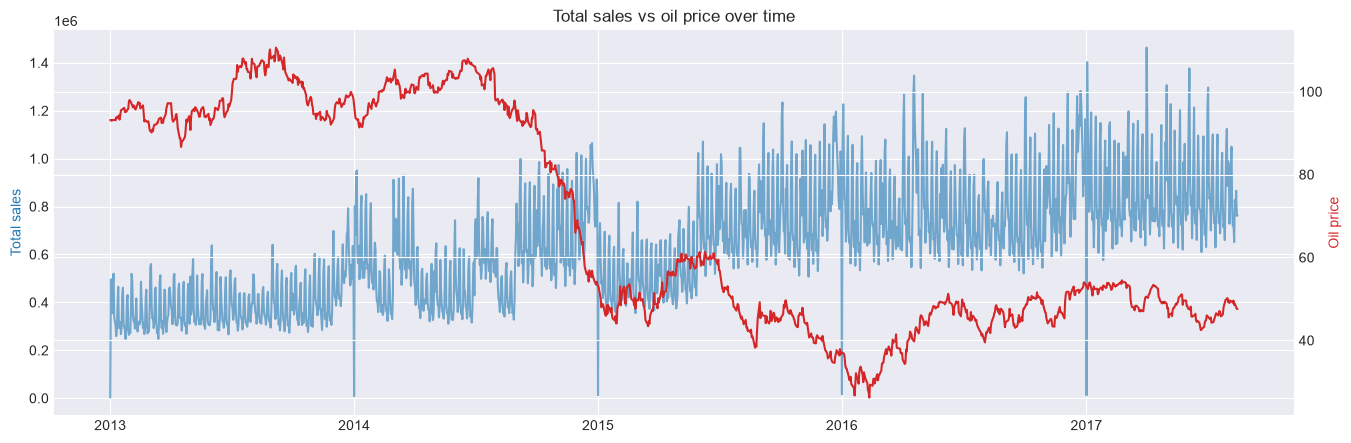


Correlation between total sales and oil price: -0.628


In [18]:
oil_sales_clean = daily_sales.reset_index().merge(oil_filled, on="date", how="left")
oil_sales_clean.columns = ["date", "total_sales", "oil_price"]

fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(oil_sales_clean["date"], oil_sales_clean["total_sales"], color="tab:blue", alpha=0.6)
ax1.set_ylabel("Total sales", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(oil_sales_clean["date"], oil_sales_clean["oil_price"], color="tab:red")
ax2.set_ylabel("Oil price", color="tab:red")

plt.title("Total sales vs oil price over time")
plt.show()

correlation = oil_sales_clean["total_sales"].corr(oil_sales_clean["oil_price"])
print(f"\nCorrelation between total sales and oil price: {correlation:.3f}")

In [19]:
print("Transactions date range:", transactions["date"].min(), "-", transactions["date"].max())
print("Test date range:", test["date"].min(), "-", test["date"].max())

Transactions date range: 2013-01-01 00:00:00 - 2017-08-15 00:00:00
Test date range: 2017-08-16 00:00:00 - 2017-08-31 00:00:00


In [20]:
sales_by_store_date = train.groupby(["date", "store_nbr"])["sales"].sum().reset_index()
merged = sales_by_store_date.merge(transactions, on=["date", "store_nbr"], how="inner")

correlation = merged["sales"].corr(merged["transactions"])
print(f"Correlation between sales and transactions: {correlation:.3f}")

Correlation between sales and transactions: 0.837


In [21]:
promo_effect = train.groupby("onpromotion")["sales"].mean()
print(promo_effect.head(10))

# quick check: average sales with vs without any promotion
train["has_promo"] = train["onpromotion"] > 0
print()
print(train.groupby("has_promo")["sales"].mean())

onpromotion
0     158.246681
1     467.556532
2     662.925632
3     871.408092
4     969.916135
5    1010.659835
6    1022.854287
7    1022.567058
8    1174.757003
9    1258.733993
Name: sales, dtype: float64

has_promo
False     158.246681
True     1137.693730
Name: sales, dtype: float64


In [22]:
train_with_store = train.merge(stores, on="store_nbr", how="left")

print("Average sales by store type:")
print(train_with_store.groupby("type")["sales"].mean().sort_values(ascending=False))

print("\nAverage sales by cluster (top 10):")
print(train_with_store.groupby("cluster")["sales"].mean().sort_values(ascending=False).head(10))

Average sales by store type:
type
A    705.878743
D    350.979407
B    326.739714
E    269.121301
C    197.263301
Name: sales, dtype: float64

Average sales by cluster (top 10):
cluster
5     1117.245254
14     708.227718
8      647.377856
11     603.507018
17     592.231511
6      342.661732
1      326.163967
12     324.461406
13     324.364108
4      296.572872
Name: sales, dtype: float64
